# 1. Introducción y Objetivos
**Autor:** Franco Michele Robotti Alonso  
**Fecha:** 15 de mayo de 2026  
**Objetivo:** Explorar el comportamiento de la cartera de préstamos y su relación con el historial de pagos, para entender la estructura de los datos y los factores asociados al riesgo de mora.

---

**Objetivos principales:**
* **Perfilamiento:** Entender la estructura, granularidad y calidad de las tablas `cartera` y `pagos`.
* **Identificación de factores:** Detectar variables asociadas al riesgo (`dias_mora`).
* **Preparación:** Generar los *insights* necesarios para la etapa de modelado predictivo.

> **Alcance de este notebook:** análisis *exploratorio*. La auditoría formal de calidad (nulos, duplicados, integridad) y las consultas analíticas se desarrollan en `01_calidad_datos` y `02_sql_analitico`.

## Diccionario de Datos

### Tabla: `cartera`
Información histórica y estado actual de los créditos otorgados.

| Campo | Tipo | Descripción |
| :--- | :--- | :--- |
| **id_prestamo** | `INT` (PK) | Identificador único del préstamo |
| **id_cliente** | `INT` | Identificador del cliente |
| **producto** | `STRING` | Tipo de producto (*Préstamo Personal, BNPL, Microcrédito, Adelanto de Sueldo*) |
| **fecha_originacion** | `DATE` | Fecha de desembolso |
| **monto_original** | `FLOAT` | Monto desembolsado en moneda local |
| **plazo_meses** | `INT` | Plazo pactado en meses |
| **tna** | `FLOAT` | Tasa nominal anual (ej: `0.48` = 48%) |
| **segmento_cliente** | `STRING` | *Nuevo / Recurrente / Premium / Inactivo* |
| **canal_adquisicion** | `STRING` | Canal de adquisición del préstamo |
| **pais** | `STRING` | País del cliente (*UY, AR, PY*) |
| **estado_actual** | `STRING` | Estado de mora al corte |
| **dias_mora** | `INT` | Días de atraso al corte (0 si está al día) |
| **saldo_capital** | `FLOAT` | Saldo de capital pendiente al corte (0 si cancelado) |

### Tabla: `pagos`
Detalle del plan de pagos y las transacciones efectivamente realizadas.

| Campo | Tipo | Descripción |
| :--- | :--- | :--- |
| **id_pago** | `INT` (PK) | Identificador único del pago |
| **id_prestamo** | `INT` (FK) | Referencia a `cartera.id_prestamo` |
| **nro_cuota** | `INT` | Número de cuota dentro del préstamo |
| **fecha_vencimiento**| `DATE` | Fecha en que vencía la cuota |
| **monto_cuota** | `FLOAT` | Importe de la cuota pactada |
| **fecha_pago_real** | `DATE` | Fecha de pago efectivo (`null` = impago) |
| **monto_pagado** | `FLOAT` | Importe pagado (0 si no pagó) |
| **dias_atraso** | `INT` | Días entre vencimiento y pago real (`null` si no pagó) |

## 2. Configuración del entorno
Importamos librerías y fijamos un estilo visual consistente, y aseguramos la carpeta de salida de figuras.

In [5]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 12
PALETA = "viridis"

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", None)

FIG_DIR = "../reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)
print("Entorno configurado.")

Entorno configurado.


## 3. Ingesta y validación de datos
Cargamos ambas hojas, validamos dimensiones y rango temporal de cada tabla.

In [6]:
DATA_PATH = "../data/raw/datasets_riesgo_v2.xlsx"

tablas = {
    "cartera": pd.read_excel(DATA_PATH, sheet_name="cartera"),
    "pagos":   pd.read_excel(DATA_PATH, sheet_name="pagos"),
}
df_cartera = tablas["cartera"]
df_pagos   = tablas["pagos"]

for nombre, df in tablas.items():
    print(f"{nombre:10s} -> {df.shape[0]:>5} filas x {df.shape[1]:>2} columnas")

cartera    ->   400 filas x 13 columnas
pagos      ->  1349 filas x  8 columnas


* **Estado de la carga:** se importaron **400** registros en `cartera` y **1.349** en `pagos`. La diferencia es esperable: una fila de `cartera` es un préstamo y una fila de `pagos` es una cuota (relación 1:N).

In [7]:
for nombre, df in tablas.items():
    print("=" * 70)
    print(nombre.upper())
    print("=" * 70)
    df.info()
    print()

CARTERA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_prestamo        400 non-null    int64  
 1   id_cliente         400 non-null    int64  
 2   producto           400 non-null    object 
 3   fecha_originacion  400 non-null    object 
 4   monto_original     400 non-null    int64  
 5   plazo_meses        400 non-null    int64  
 6   tna                400 non-null    float64
 7   segmento_cliente   400 non-null    object 
 8   canal_adquisicion  400 non-null    object 
 9   pais               400 non-null    object 
 10  estado_actual      400 non-null    object 
 11  dias_mora          400 non-null    int64  
 12  saldo_capital      400 non-null    float64
dtypes: float64(2), int64(5), object(6)
memory usage: 40.8+ KB

PAGOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1349 entries, 0 to 1348
Data columns (total 8 c

### 3.1. Normalización de tipos
Convertimos las columnas de fecha de `object` a `datetime` mediante un bucle, para no repetir código.

In [8]:
fechas_por_tabla = {
    "cartera": ["fecha_originacion"],
    "pagos":   ["fecha_vencimiento", "fecha_pago_real"],
}
for nombre, cols in fechas_por_tabla.items():
    for c in cols:
        tablas[nombre][c] = pd.to_datetime(tablas[nombre][c], errors="coerce")

print("Cartera  | fecha_originacion:",
      df_cartera["fecha_originacion"].min().date(), "->",
      df_cartera["fecha_originacion"].max().date())
print("Pagos    | fecha_vencimiento:",
      df_pagos["fecha_vencimiento"].min().date(), "->",
      df_pagos["fecha_vencimiento"].max().date())

Cartera  | fecha_originacion: 2022-01-01 -> 2024-06-29
Pagos    | fecha_vencimiento: 2022-01-31 -> 2025-03-03


In [9]:
def mostrar_descripcion(df, nombre):
    print(f"Estadísticos descriptivos - {nombre}:")
    display(df.describe())

mostrar_descripcion(df_cartera, "cartera")
mostrar_descripcion(df_pagos, "pagos")

Estadísticos descriptivos - cartera:


,id_prestamo,id_cliente,fecha_originacion,monto_original,plazo_meses,tna,dias_mora,saldo_capital
count,400.00,400.00,400,400.00,400.00,400.00,400.00,400.00
mean,"10,199.50","1,127.13",2023-03-29 13:12:00,"19,716.00",6.44,0.44,27.62,"10,181.25"
min,"10,000.00","1,000.00",2022-01-01 00:00:00,700.00,1.00,0.30,0.00,0.00
25%,"10,099.75","1,068.00",2022-09-08 00:00:00,"6,900.00",2.00,0.34,0.00,"2,303.94"
50%,"10,199.50","1,128.00",2023-03-23 12:00:00,"13,000.00",5.00,0.48,0.00,"5,533.16"
75%,"10,299.25","1,189.00",2023-11-09 18:00:00,"23,425.00",9.00,0.48,33.00,"12,555.58"
max,"10,399.00","1,248.00",2024-06-29 00:00:00,"80,000.00",24.00,0.62,288.00,"76,173.54"
std,115.61,70.04,NaN,"19,451.59",5.66,0.12,56.39,"12,605.10"


Estadísticos descriptivos - pagos:


,id_pago,id_prestamo,nro_cuota,fecha_vencimiento,monto_cuota,fecha_pago_real,monto_pagado,dias_atraso
count,"1,349.00","1,349.00","1,349.00",1349,"1,349.00",1198,"1,349.00","1,198.00"
mean,"50,674.00","10,205.33",3.33,2023-06-25 17:17:34.114158592,"3,569.41",2023-07-03 05:54:35.459098368,"2,794.71",4.79
min,"50,000.00","10,000.00",1.00,2022-01-31 00:00:00,210.33,2022-02-01 00:00:00,0.00,0.00
25%,"50,337.00","10,106.00",1.00,2022-11-22 00:00:00,"1,348.05",2022-11-29 00:00:00,828.24,0.00
50%,"50,674.00","10,208.00",3.00,2023-06-20 00:00:00,"2,612.24",2023-07-02 12:00:00,"2,017.99",0.00
75%,"51,011.00","10,309.00",5.00,2024-02-06 00:00:00,"4,206.67",2024-02-09 00:00:00,"3,618.89",4.00
max,"51,348.00","10,399.00",12.00,2025-03-03 00:00:00,"72,176.00",2025-03-03 00:00:00,"64,573.53",45.00
std,389.57,115.66,2.48,NaN,"4,667.25",NaN,"4,013.15",9.99


### Conclusiones del perfilamiento

* **Alta dispersión de la mora:** `dias_mora` tiene media **27.6** y desvío **56.4** (máx. 288). Conviven una mayoría de créditos al día (241/400 ≈ **60%**) con una cola de casos severos.
* **Saldos muy variables:** `saldo_capital` va de **0** a **76.174** (potenciales *outliers* para un modelo).
* **Corrección importante sobre `dias_atraso`:** los **151** nulos coinciden *exactamente* con `fecha_pago_real` nula y `monto_pagado = 0`. **No son pagos puntuales: son cuotas impagas.** Imputarlos como `0` trataría un impago como pago a tiempo y sesgaría el análisis. Se deben marcar con un flag `impago` y tratarse aparte.
* **`monto_pagado = 0`:** los 151 casos de monto cero son justamente esos impagos, no errores de carga.

## 4. Granularidad, cobertura e integridad referencial
Antes de cruzar tablas fijamos la **unidad de análisis** y verificamos que la relación `pagos → cartera` cierra.

In [10]:
pagos_por_prestamo = df_pagos.groupby("id_prestamo").size()
print("Cuotas por prestamo  -> min:", pagos_por_prestamo.min(),
      "| mediana:", int(pagos_por_prestamo.median()),
      "| media:", round(pagos_por_prestamo.mean(), 2),
      "| max:", pagos_por_prestamo.max())

prestamos_cartera = df_cartera["id_prestamo"].nunique()
prestamos_con_pagos = df_pagos["id_prestamo"].nunique()
huerfanos = (~df_pagos["id_prestamo"].isin(df_cartera["id_prestamo"])).sum()
print("\nPrestamos en cartera        :", prestamos_cartera)
print("Prestamos con al menos 1 pago:", prestamos_con_pagos)
print("Prestamos SIN pagos          :", prestamos_cartera - prestamos_con_pagos)
print("Pagos huerfanos              :", huerfanos)

print("\nClientes unicos en cartera   :", df_cartera["id_cliente"].nunique())
print("Max. prestamos por cliente   :", df_cartera["id_cliente"].value_counts().max())

Cuotas por prestamo  -> min: 1 | mediana: 2 | media: 3.37 | max: 12

Prestamos en cartera        : 400
Prestamos con al menos 1 pago: 400
Prestamos SIN pagos          : 0
Pagos huerfanos              : 0

Clientes unicos en cartera   : 194
Max. prestamos por cliente   : 5


**Interpretación y hallazgos:**
* **Unidad de análisis = el préstamo.** Hay **400 préstamos** en **194 clientes** (hasta 5 por cliente); las métricas de riesgo se calculan a nivel préstamo, no cliente.
* **Integridad referencial intacta:** los 400 préstamos tienen pagos asociados (0 sin pagos) y **no hay pagos huérfanos** → el join `pagos → cartera` es seguro.
* **Grano de pagos:** en promedio **3.4 cuotas por préstamo** (hasta 12).

## 5. Análisis univariante
Distribución de las variables clave para entender su comportamiento y detectar sesgos y *outliers*.

### 5.1. Distribución de la morosidad

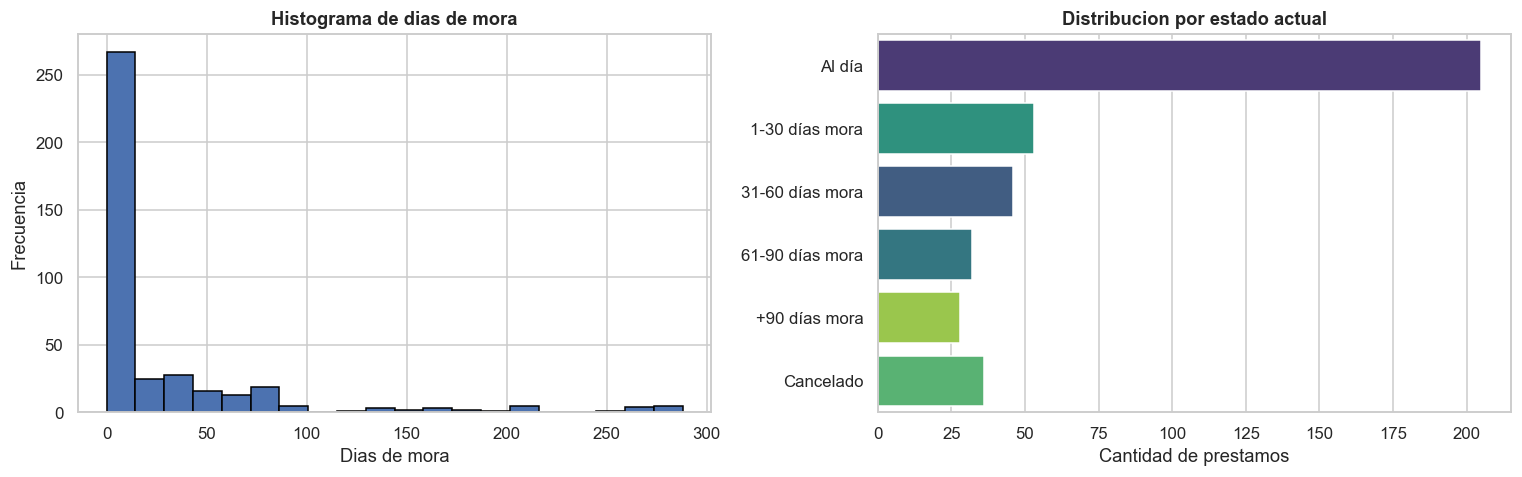

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

df_cartera["dias_mora"].hist(bins=20, edgecolor="black", ax=axes[0])
axes[0].set_title("Histograma de dias de mora")
axes[0].set_xlabel("Dias de mora"); axes[0].set_ylabel("Frecuencia")

orden_estado = ["Al día", "1-30 días mora", "31-60 días mora",
                "61-90 días mora", "+90 días mora", "Cancelado"]
sns.countplot(data=df_cartera, y="estado_actual", order=orden_estado,
              hue="estado_actual", palette=PALETA, legend=False, ax=axes[1])
axes[1].set_title("Distribucion por estado actual")
axes[1].set_xlabel("Cantidad de prestamos"); axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/00_dist_morosidad.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretación y hallazgos:**
* La mayoría de los créditos está **al día** (205) o cancelado (36), pero hay una cola de mora que llega a casi 300 días → fuerte **asimetría positiva**.
* Sumando todos los tramos, **~35%** de la cartera presenta algún grado de mora.
* **Acción:** categorizar `dias_mora` en niveles de riesgo en lugar de usarla como variable continua cruda.

### 5.2. Outliers en saldo capital

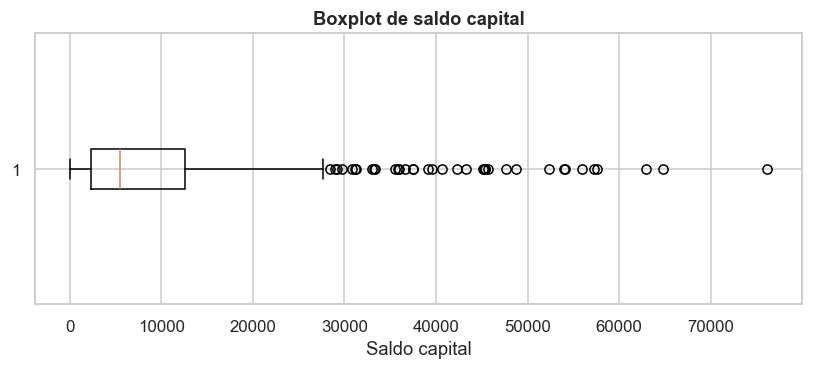

In [13]:
plt.figure(figsize=(9, 3.2))
plt.boxplot(df_cartera["saldo_capital"], vert=False)
plt.title("Boxplot de saldo capital")
plt.xlabel("Saldo capital")
plt.savefig(f"{FIG_DIR}/00_boxplot_saldo_capital.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretación y hallazgos:**
* La caja se concentra en valores bajos con numerosos puntos a la derecha → **outliers** de gran magnitud.
* **Acción:** evaluar transformación logarítmica o tratamiento de extremos antes de modelar.

### 5.3. Variables categóricas de la cartera
Verificamos el balance de las dimensiones de segmentación.

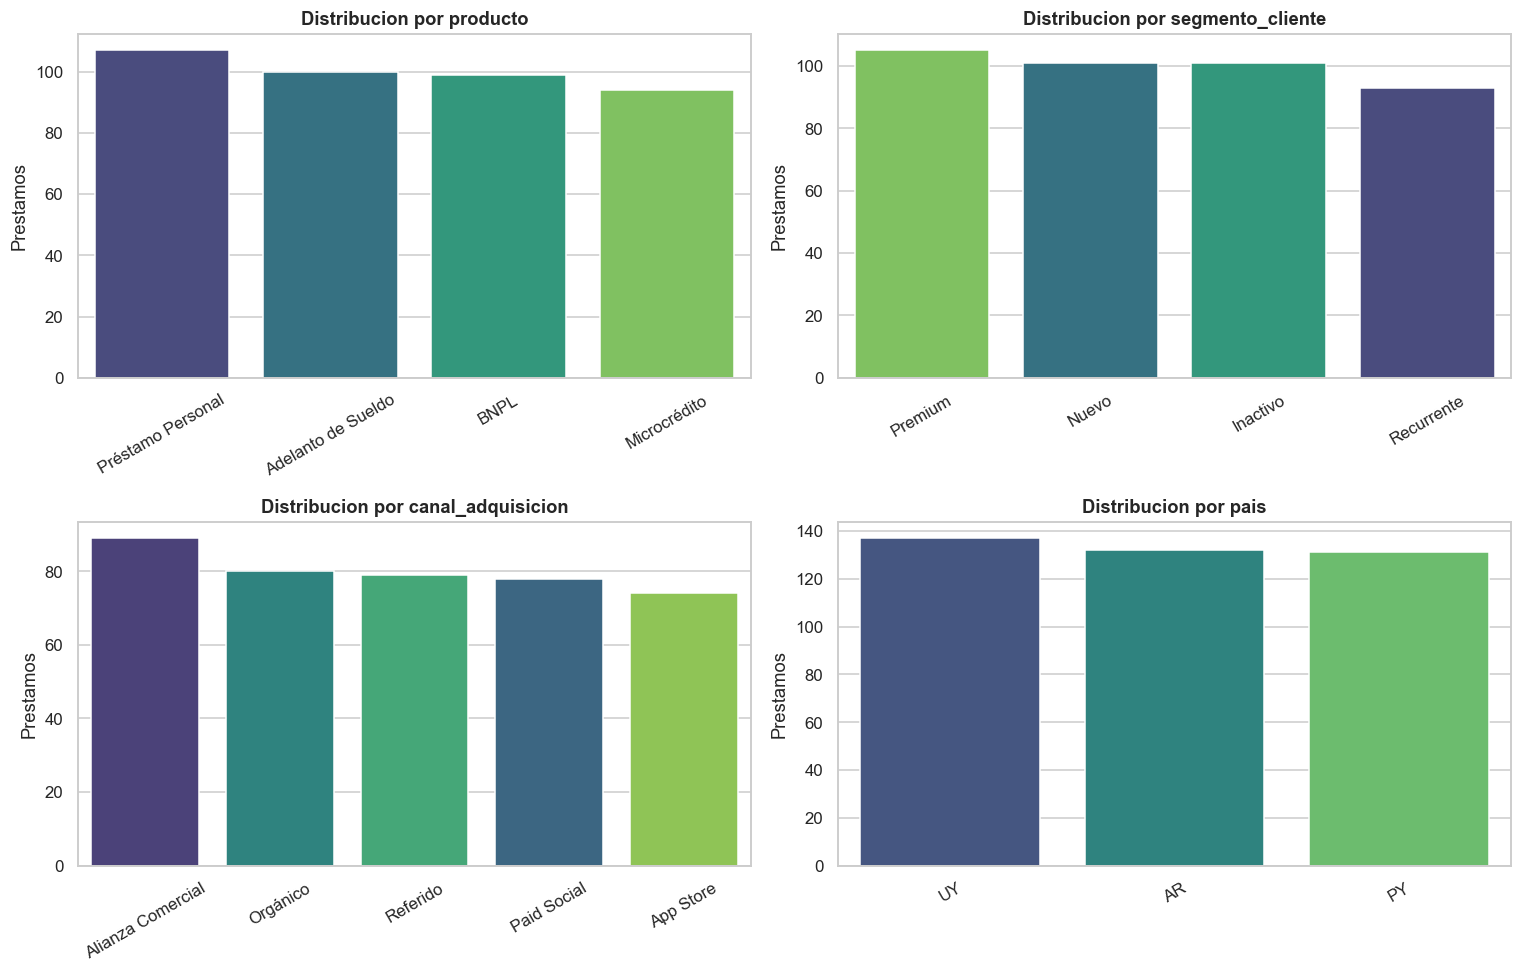

In [14]:
cat_cols = ["producto", "segmento_cliente", "canal_adquisicion", "pais"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    orden = df_cartera[col].value_counts().index
    sns.countplot(data=df_cartera, x=col, order=orden,
                  hue=col, palette=PALETA, legend=False, ax=ax)
    ax.set_title(f"Distribucion por {col}")
    ax.set_xlabel(""); ax.set_ylabel("Prestamos")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/00_categoricas_cartera.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretación y hallazgos:**
* Las cuatro dimensiones están **razonablemente balanceadas**: productos 94–107, segmentos 93–105, países ~131–137. No hay clases minoritarias extremas.
* Esto da confianza para calcular **tasas de mora por categoría** (sección 6) sin que el tamaño de grupo distorsione.

### 5.4. Variables numéricas del crédito (monto, plazo, TNA)

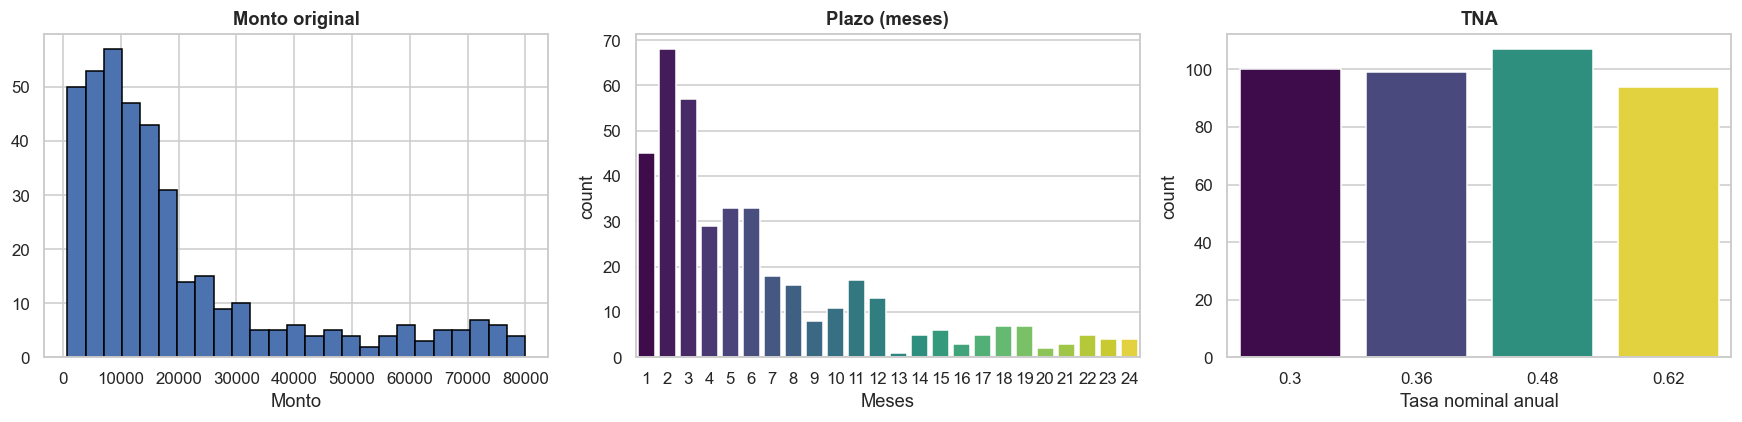

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df_cartera["monto_original"].hist(bins=25, edgecolor="black", ax=axes[0])
axes[0].set_title("Monto original"); axes[0].set_xlabel("Monto")

sns.countplot(data=df_cartera, x="plazo_meses",
              hue="plazo_meses", palette=PALETA, legend=False, ax=axes[1])
axes[1].set_title("Plazo (meses)"); axes[1].set_xlabel("Meses")

sns.countplot(data=df_cartera, x="tna",
              hue="tna", palette=PALETA, legend=False, ax=axes[2])
axes[2].set_title("TNA"); axes[2].set_xlabel("Tasa nominal anual")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/00_numericas_credito.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretación y hallazgos:**
* `monto_original` está sesgado a la derecha (muchos montos chicos, pocos grandes).
* La **TNA toma solo 4 valores** (0.30, 0.36, 0.48, 0.62): políticas de tasa estandarizadas, no una variable continua → tratarla como **categórica**.

### 5.5. Comportamiento de pagos (impagos y atraso)
Cuantificamos los impagos detectados en el perfilamiento y el atraso entre las cuotas que sí se pagaron.

Cuotas impagas: 151 (11.2% del total)


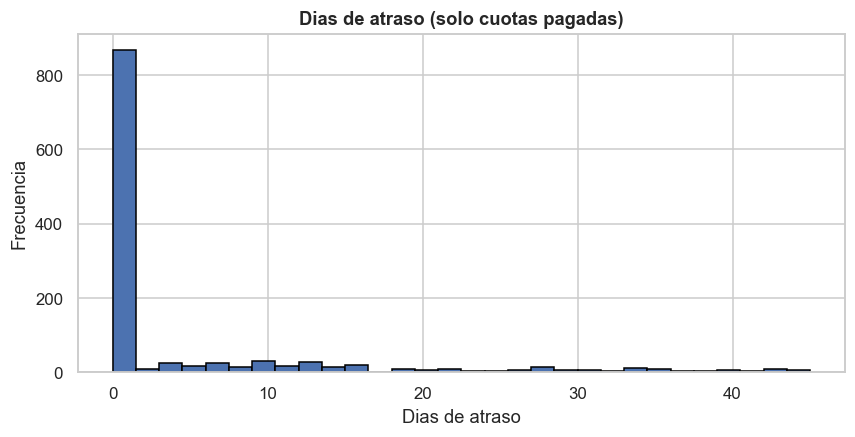


Atraso medio en cuotas pagadas: 4.8 dias
Cuotas pagadas a tiempo (atraso 0): 857 (71.5%)


In [16]:
impagos = df_pagos["fecha_pago_real"].isnull()
print("Cuotas impagas:", impagos.sum(), f"({impagos.mean()*100:.1f}% del total)")

pagadas = df_pagos.loc[~impagos]
plt.figure(figsize=(9, 4))
pagadas["dias_atraso"].hist(bins=30, edgecolor="black")
plt.title("Dias de atraso (solo cuotas pagadas)")
plt.xlabel("Dias de atraso"); plt.ylabel("Frecuencia")
plt.savefig(f"{FIG_DIR}/00_dist_dias_atraso.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nAtraso medio en cuotas pagadas:", round(pagadas["dias_atraso"].mean(), 1), "dias")
print("Cuotas pagadas a tiempo (atraso 0):",
      (pagadas["dias_atraso"] == 0).sum(), f"({(pagadas['dias_atraso']==0).mean()*100:.1f}%)")

**Interpretación y hallazgos:**
* **151 cuotas (11.2%)** quedaron impagas y se aíslan correctamente (no se imputan como atraso 0).
* Entre las pagadas, una parte se abona con atraso → existe **morosidad transitoria** que `estado_actual` (foto al corte) no captura. Esto motiva *feature engineering* sobre `pagos`.

## 6. Análisis bivariante: tasa de mora por categoría
Definimos una variable binaria de mora (>30 días) y calculamos la **tasa de mora** por cada dimensión. La media global de referencia es **26.5%**.

Tasa de mora (>30 dias) GLOBAL: 26.5%



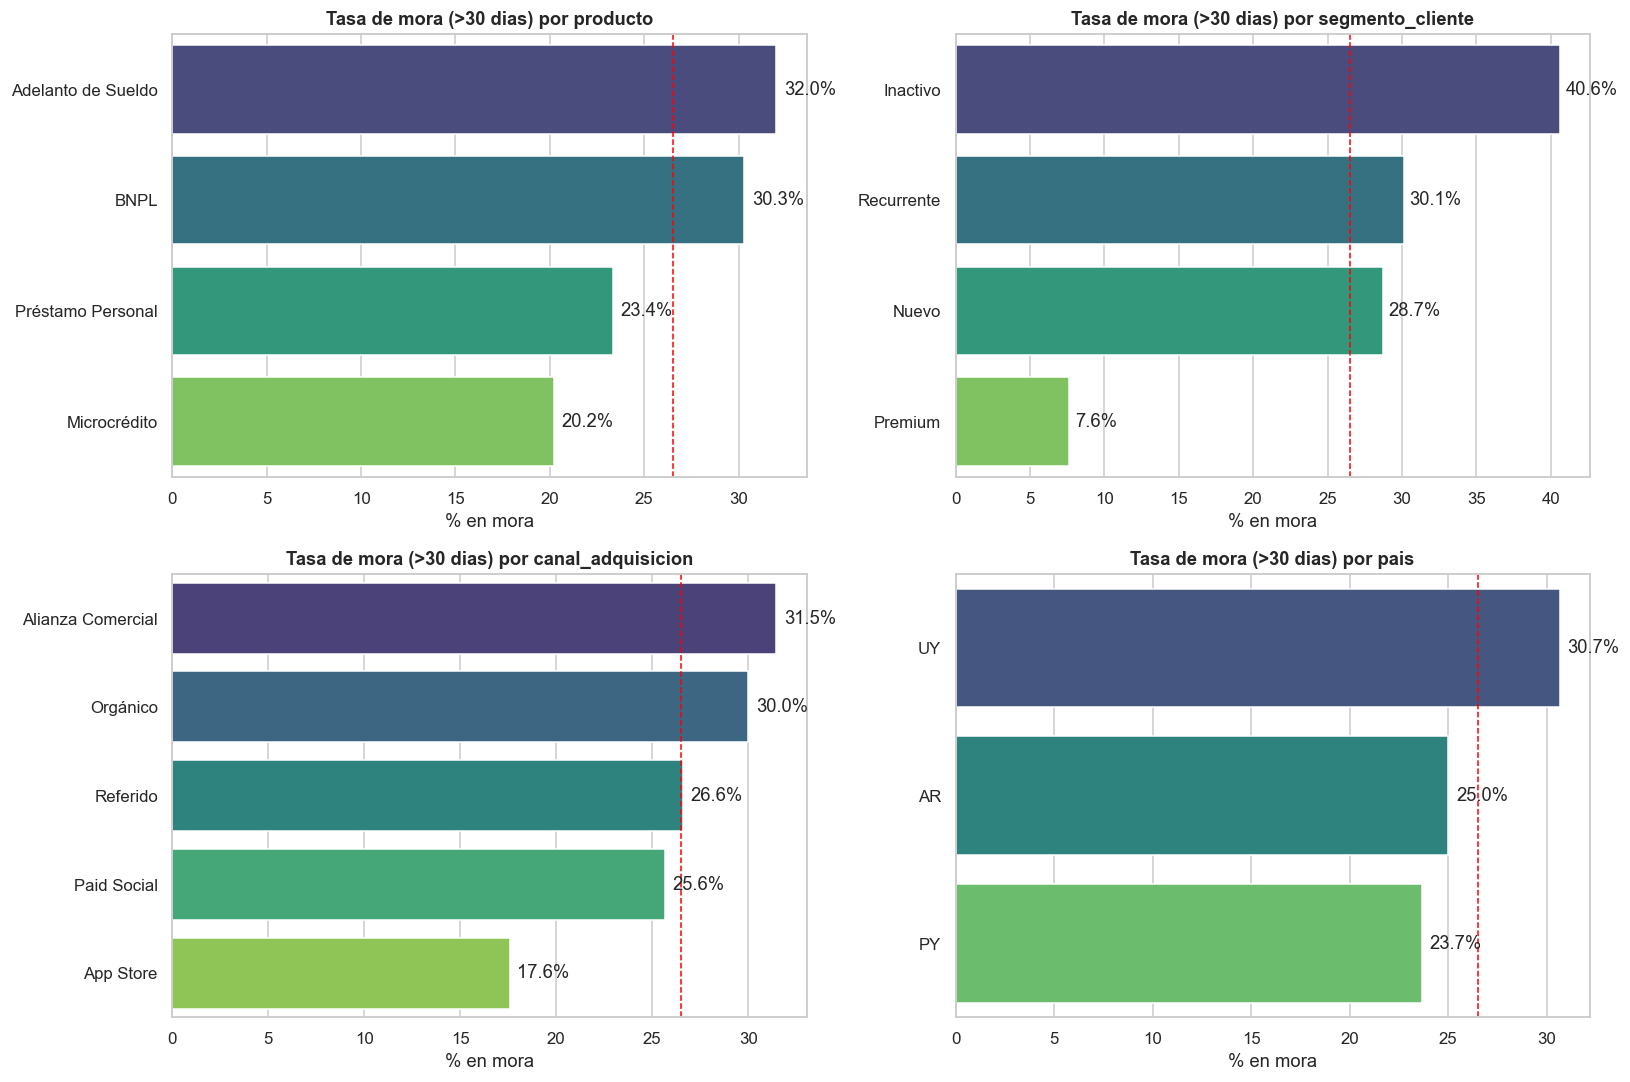

In [17]:
df_cartera["en_mora_30"] = (df_cartera["dias_mora"] > 30).astype(int)
tasa_global = df_cartera["en_mora_30"].mean()
print(f"Tasa de mora (>30 dias) GLOBAL: {tasa_global*100:.1f}%\n")

categoricas = ["producto", "segmento_cliente", "canal_adquisicion", "pais"]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, col in zip(axes.ravel(), categoricas):
    resumen = (df_cartera.groupby(col)["en_mora_30"].mean()
               .sort_values(ascending=False))
    sns.barplot(x=resumen.values * 100, y=resumen.index,
                hue=resumen.index, palette=PALETA, legend=False, ax=ax)
    ax.axvline(tasa_global * 100, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"Tasa de mora (>30 dias) por {col}")
    ax.set_xlabel("% en mora"); ax.set_ylabel("")
    for i, v in enumerate(resumen.values * 100):
        ax.text(v + 0.4, i, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/00_tasa_mora_por_categoria.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretación y hallazgos** *(línea roja = media global 26.5%)*:

* **Por producto:** **Adelanto de Sueldo (32.0%)** y **BNPL (30.3%)** son los más riesgosos; **Microcrédito (20.2%)** el más sano. Brecha de ~12 pp.
  > **Insight:** revisar las políticas de aprobación de *Adelanto de Sueldo* y *BNPL* (ticket chico y aprobación ágil), donde la baja fricción se traduce en mayor mora.

* **Por segmento:** el peor es **Inactivo (40.6%)**, seguido de Recurrente (30.1%) y Nuevo (28.7%). **Premium es por lejos el más sano (7.6%)**.
  > **Insight:** el foco de cobranza temprana está en el segmento *Inactivo*; *Premium* funciona como ancla de bajo riesgo.

* **Por canal:** **Alianza Comercial (31.5%)** y **Orgánico (30.0%)** lideran la mora; **App Store (17.6%)** es el más bajo.
  > **Insight:** los créditos por alianzas requieren reforzar el scoring de entrada.

* **Por país:** **UY (30.7%) > AR (25.0%) > PY (23.7%)**. Diferencias moderadas; el país no es el driver principal.

## 7. Tendencia temporal del riesgo
Volumen de originaciones por mes y evolución de la tasa de mora por año de originación.

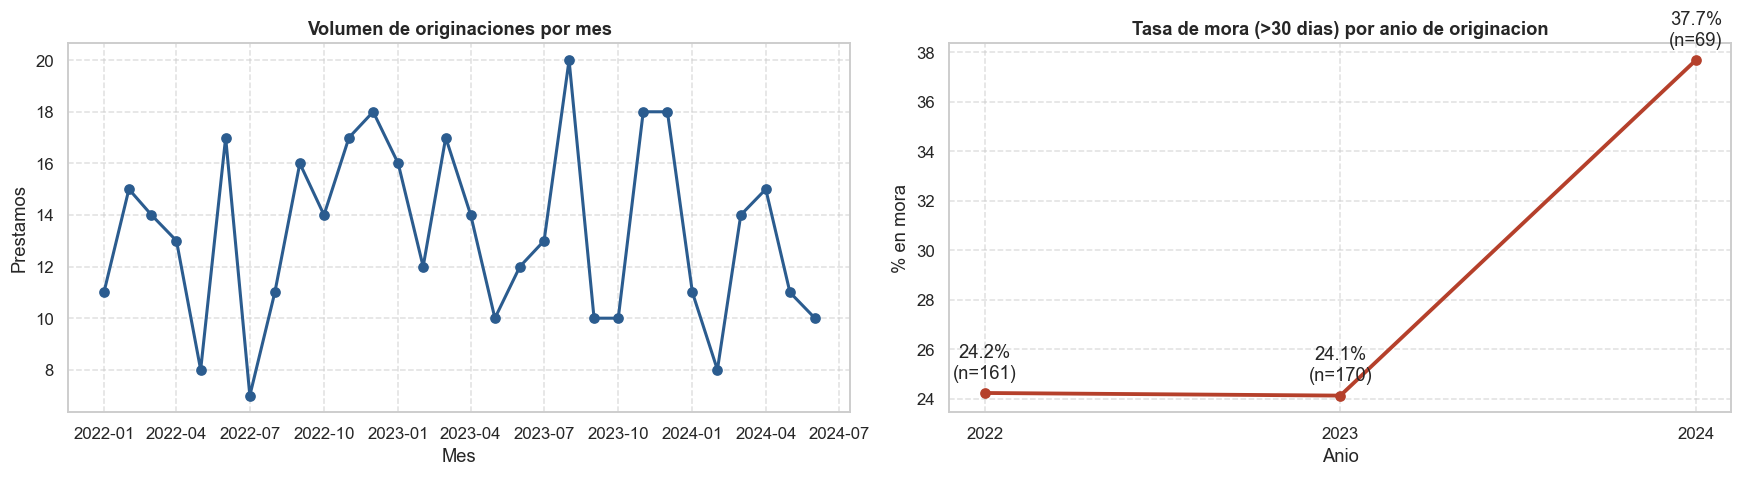

In [18]:
df_cartera["anio_originacion"] = df_cartera["fecha_originacion"].dt.year
df_cartera["mes_originacion"] = (df_cartera["fecha_originacion"]
                                 .dt.to_period("M").dt.to_timestamp())

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

vol = df_cartera.groupby("mes_originacion").size()
axes[0].plot(vol.index, vol.values, marker="o", linewidth=2, color="#2b5c8f")
axes[0].set_title("Volumen de originaciones por mes")
axes[0].set_xlabel("Mes"); axes[0].set_ylabel("Prestamos")
axes[0].grid(True, linestyle="--", alpha=0.6)

resumen_anio = df_cartera.groupby("anio_originacion")["en_mora_30"].agg(["mean", "count"])
axes[1].plot(resumen_anio.index, resumen_anio["mean"] * 100,
             marker="o", linewidth=2.5, color="#b5402b")
for x, (m, n) in resumen_anio.iterrows():
    axes[1].text(x, m * 100 + 0.6, f"{m*100:.1f}%\n(n={int(n)})", ha="center")
axes[1].set_title("Tasa de mora (>30 dias) por anio de originacion")
axes[1].set_xlabel("Anio"); axes[1].set_ylabel("% en mora")
axes[1].set_xticks(resumen_anio.index)
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/00_tendencia_temporal.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretación y hallazgos:**
* **2022 (24.2%)** y **2023 (24.1%)** se mantienen estables.
* En **2024 la tasa salta a 37.7%** → señal de deterioro en las cosechas recientes.
* **Cautela estadística:** 2024 tiene solo **69 préstamos** y la última originación es de **junio 2024** (año parcial). El salto es una alerta a monitorear, pero con muestra chica conviene confirmarlo con más datos antes de accionar.

## 8. Factores de riesgo: saldo y TNA vs. mora
Exploramos si las variables estáticas del crédito explican el comportamiento de pago.

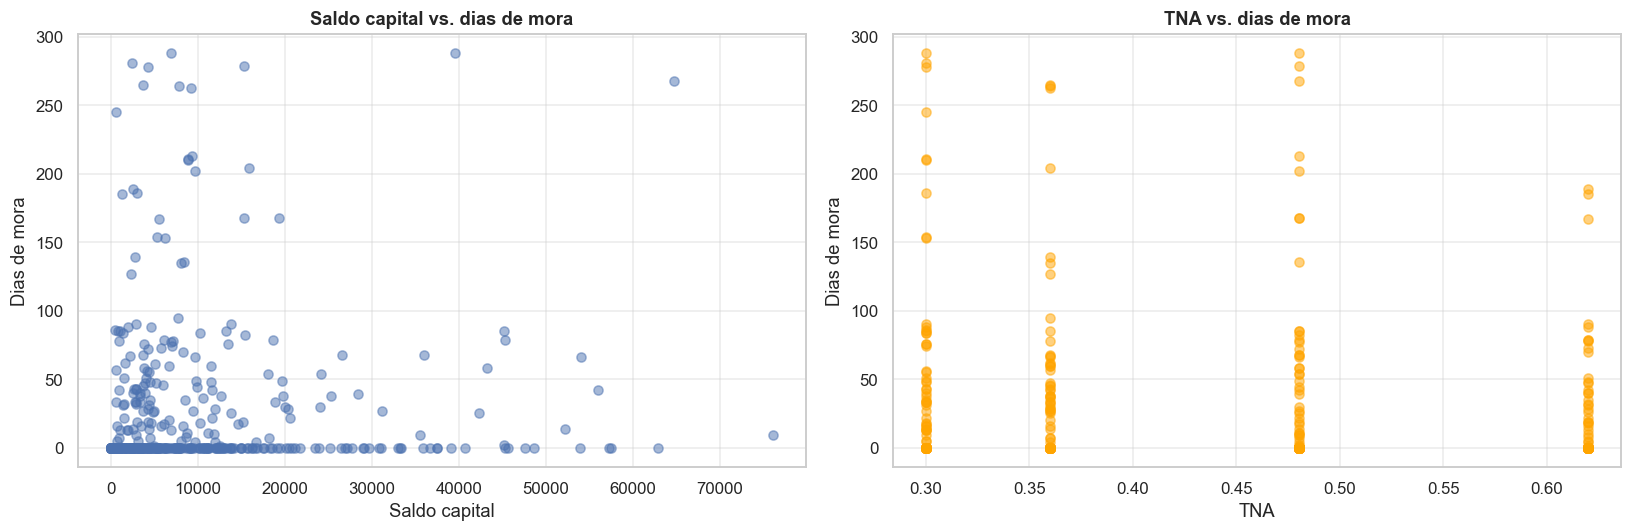

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].scatter(df_cartera["saldo_capital"], df_cartera["dias_mora"], alpha=0.5)
axes[0].set_title("Saldo capital vs. dias de mora")
axes[0].set_xlabel("Saldo capital"); axes[0].set_ylabel("Dias de mora")
axes[0].grid(True, alpha=0.4)

axes[1].scatter(df_cartera["tna"], df_cartera["dias_mora"], alpha=0.5, color="orange")
axes[1].set_title("TNA vs. dias de mora")
axes[1].set_xlabel("TNA"); axes[1].set_ylabel("Dias de mora")
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/00_factores_riesgo.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretación y hallazgos:**
* **Saldo capital vs. mora:** sin relación lineal (corr ≈ 0.05). El riesgo es independiente del tamaño del préstamo.
* **TNA vs. mora:** la TNA se agrupa en 4 niveles y la mora se dispersa igual en todos (corr ≈ -0.10): **no es predictor determinante**.
* **Conclusión:** las variables estáticas no explican la mora → hace falta **feature engineering** sobre `pagos` (atraso histórico, cuotas impagas, ratio pagado/pactado).

## 9. Matriz de correlación
Detectamos relaciones lineales y posible **multicolinealidad** entre variables numéricas.

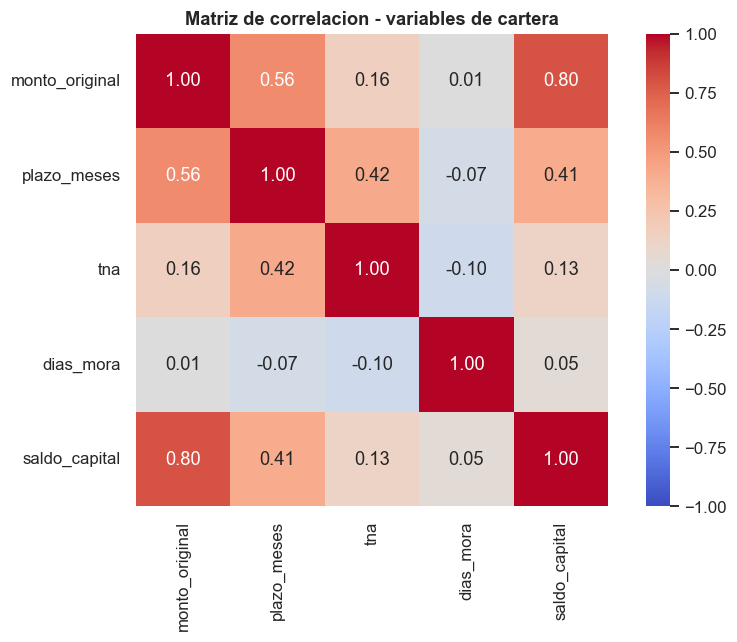

In [20]:
columnas_interes = ["monto_original", "plazo_meses", "tna", "dias_mora", "saldo_capital"]
matriz_corr = df_cartera[columnas_interes].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f",
            vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlacion - variables de cartera")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/00_matriz_correlacion.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretación y hallazgos:**
* **Multicolinealidad:** `monto_original` ↔ `saldo_capital` = **0.80** → conservar `saldo_capital` y descartar `monto_original` en el modelado.
* **Debilidad predictiva:** todas las correlaciones de `dias_mora` con las estáticas son ≈ 0. El riesgo no se explica con monto, plazo o tasa por sí solos.

## 10. Síntesis de hallazgos exploratorios

| # | Hallazgo | Evidencia | Acción sugerida |
|:-:|:---|:---|:---|
| 1 | La mora se concentra en pocos casos severos | media 27.6 / desvío 56.4; 60% al día | Categorizar mora en niveles de riesgo |
| 2 | **151 cuotas impagas mal clasificables** | `fecha_pago_real` nula = `monto_pagado` 0 = `dias_atraso` nulo | Flag `impago`; **no** imputar atraso 0 |
| 3 | Integridad y grano OK | 400 préstamos, 0 huérfanos, 3.4 cuotas/préstamo | Unidad de análisis = préstamo |
| 4 | Mora muy desigual por **segmento** | Inactivo 40.6% vs. Premium 7.6% | Reforzar cobranza temprana en Inactivo |
| 5 | Productos de baja fricción más riesgosos | Adelanto de Sueldo 32% / BNPL 30% | Revisar política de aprobación |
| 6 | Posible deterioro en cosecha 2024 | 37.7% vs. ~24% previo (n=69, parcial) | Monitorear; validar con más datos |
| 7 | Variables estáticas no predicen mora | correlaciones ≈ 0 con `dias_mora` | Feature engineering sobre `pagos` |

**Próximos pasos:** formalizar la auditoría de calidad (`01_calidad_datos`), en particular el tratamiento de los 151 impagos y la consistencia cronológica de pagos, y construir las variables de comportamiento para el modelado.